### Imports

In [12]:
%pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 9.9/9.9 MB 81.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [16]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [50]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [28]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

### Data Loader

In [27]:
# This is where your files actually live
data_path = r"C:\Users\solisrv\OneDrive - beloit.edu\Desktop\MIND\MINDsmall_train"

# Verify the path by listing files
print("Files in directory:", os.listdir(data_path))

# Load News Data
news_cols = ['news_id', 'category', 'subcategory', 'title',
             'abstract', 'url', 'title_entities', 'abstract_entities']

news_df = pd.read_csv(os.path.join(data_path, 'news.tsv'),
                       sep='\t', names=news_cols)
#Load Behaviors Data
beh_cols = ['impression_id', 'user_id', 'time', 'history', 'impressions']
behaviors_df = pd.read_csv(os.path.join(data_path, 'behaviors.tsv'),
                       sep='\t', names=beh_cols)

print(f"Loaded {len(news_df)} news articles.")
print(news_df.head())


Files in directory: ['behaviors.tsv', 'entity_embedding.vec', 'news.tsv', 'relation_embedding.vec']
Loaded 51282 news articles.
  news_id   category      subcategory  \
0  N55528  lifestyle  lifestyleroyals   
1  N19639     health       weightloss   
2  N61837       news        newsworld   
3  N53526     health           voices   
4  N38324     health          medical   

                                               title  \
0  The Brands Queen Elizabeth, Prince Charles, an...   
1                      50 Worst Habits For Belly Fat   
2  The Cost of Trump's Aid Freeze in the Trenches...   
3  I Was An NBA Wife. Here's How It Affected My M...   
4  How to Get Rid of Skin Tags, According to a De...   

                                            abstract  \
0  Shop the notebooks, jackets, and more that the...   
1  These seemingly harmless habits are holding yo...   
2  Lt. Ivan Molchanets peeked over a parapet of s...   
3  I felt like I was a fraud, and being an NBA wi...   
4  They 

### Basic Statistics

In [25]:
# Basic statistics
print(f'Total news articles: {len(news_df)}')
print(f'Total users: {behaviors_df["user_id"].nunique()}')
print(f'Total impressions: {len(behaviors_df)}')

Total news articles: 51282
Total users: 50000
Total impressions: 156965


### Category Distribution

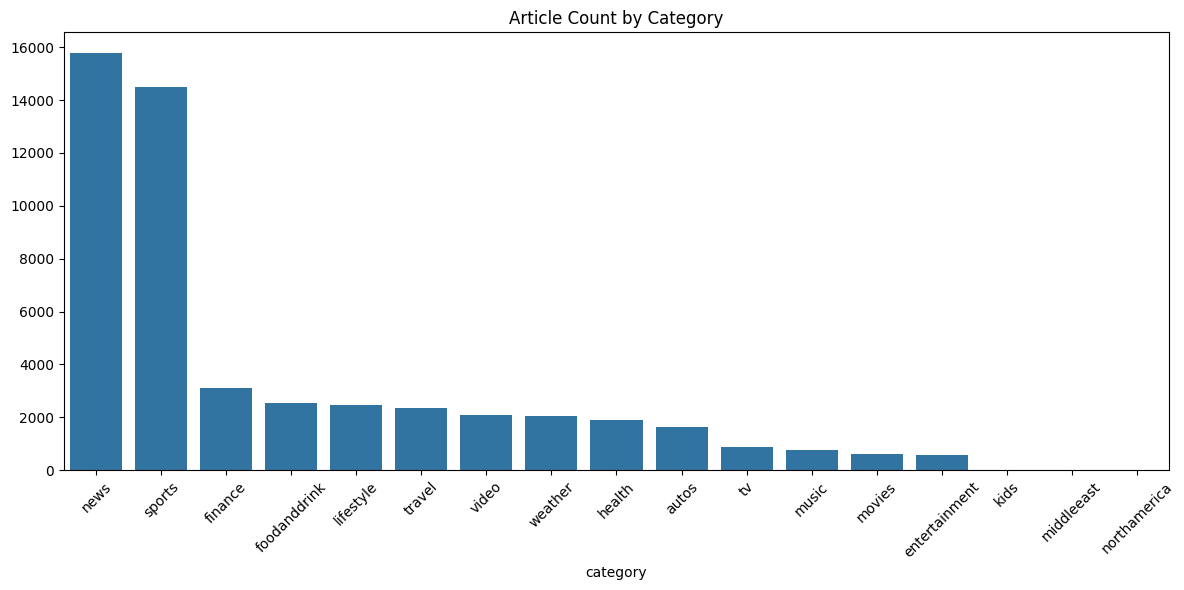

In [30]:
# Category distribution
# Create the results directory if it doesn't exist
os.makedirs('results', exist_ok=True)

cat_counts = news_df['category'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=cat_counts.index, y=cat_counts.values)
plt.title('Article Count by Category')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('results/category_distribution.png')
plt.show()

## Interpretation - Category Distribution 
The category distribution shows that a small number of categories dominate the dataset while several categories appear infrequently. News and sports have signigicantly more article counts. This imbalance suggests potential bias where models may learn majority-category patterns better than minority ones - a data quality concern is class imbalance, which may require weighting or resampling during training.

### User Activity Distribution

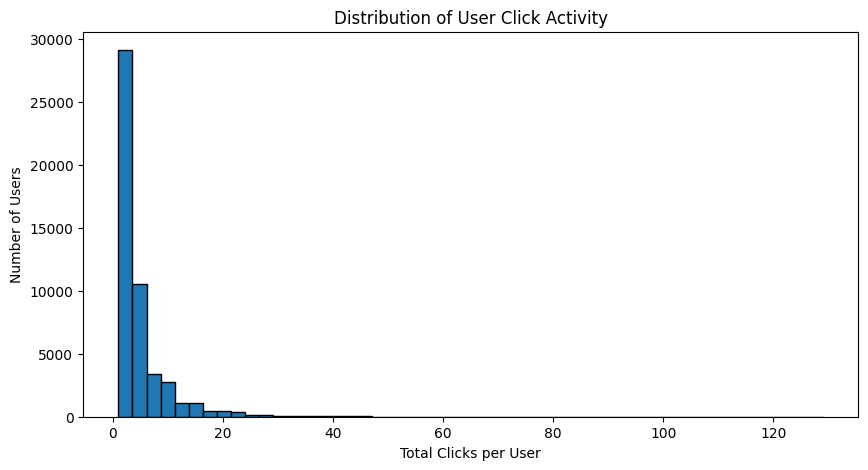

In [31]:
# User click distribution
def count_clicks(imp_str):
    if pd.isna(imp_str): return 0
    return sum(1 for x in imp_str.split() if x.endswith('-1'))
behaviors_df['n_clicks'] = behaviors_df['impressions'].apply(count_clicks)

user_clicks = behaviors_df.groupby('user_id')['n_clicks'].sum()
plt.figure(figsize=(10, 5))
plt.hist(user_clicks, bins=50, edgecolor='black')
plt.xlabel('Total Clicks per User')
plt.ylabel('Number of Users')
plt.title('Distribution of User Click Activity')
plt.savefig('results/user_click_dist.png')

## Interpretation — Distribution of User Click Activity

The distribution of user click activity is highly skewed, showing that most users generate only a small number of clicks while a small minority of users are extremely active. This indicates a long-tail engagement pattern where a few heavy users contribute disproportionately to overall interaction volume. A potential data quality issue is user activity imbalance, which may bias models toward highly active users and reduce performance for low-activity or new users.

#### Percentage of Users with Less than 10 Clicks

In [37]:
# We count how many times '-1' (a click) appears in the impressions string
behaviors_df['click_count'] = behaviors_df['impressions'].str.count('-1')
user_clicks = behaviors_df.groupby('user_id')['click_count'].sum()

# 3. Calculate Percentage of users with < 10 clicks
low_click_users = user_clicks[user_clicks < 10]
pct_low_clicks = (len(low_click_users) / len(user_clicks)) * 100

#### Log-Log - Power-Law Behavior

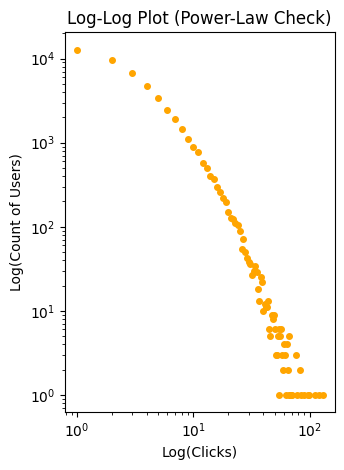

In [38]:
# Plot 2: Log-Log Plot (To identify Power-Law behavior)
# Power-law distributions appear as a straight line on a log-log scale
plt.subplot(1, 2, 2)
counts = user_clicks.value_counts().sort_index()
plt.loglog(counts.index, counts.values, 'o', markersize=4, color='orange')
plt.title('Log-Log Plot (Power-Law Check)')
plt.xlabel('Log(Clicks)')
plt.ylabel('Log(Count of Users)')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/user_activity_powerlaw.png')
plt.show()

## Interpretation - Log-Log 
The log-log visualization suggests approximate power-law behavior, confirming that user engagement follows a heavy-tailed distribution. A small number of users contribute disproportionately to total activity. This distribution highlights a potential data imbalance issue that could bias evaluation metrics if not handled carefully.

### History Length Analysis

#### History Length Stats

In [39]:
# 1. Calculate history lengths
# We split the string by space and get the length. If NaN, length is 0.
behaviors_df['history_length'] = behaviors_df['history'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

# 2. Calculate Statistics
mean_hist = behaviors_df['history_length'].mean()
median_hist = behaviors_df['history_length'].median()
p90_hist = behaviors_df['history_length'].quantile(0.90)

print(f"--- History Length Statistics ---")
print(f"Mean:   {mean_hist:.2f}")
print(f"Median: {median_hist:.2f}")
print(f"90th Percentile: {p90_hist:.2f}")

--- History Length Statistics ---
Mean:   32.54
Median: 19.00
90th Percentile: 78.00


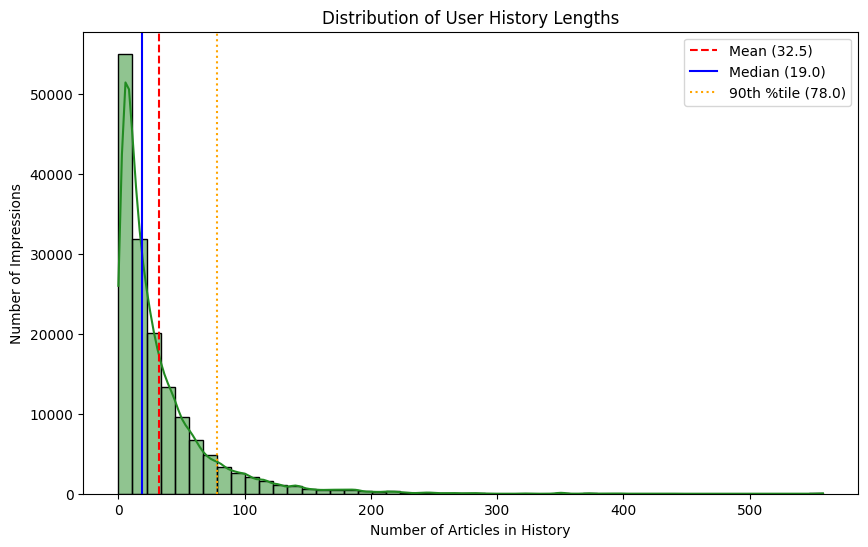

In [41]:
# 3. Visualization
plt.figure(figsize=(10, 6))
sns.histplot(behaviors_df['history_length'], bins=50, kde=True, color='forestgreen')

# Add vertical lines for the stats
plt.axvline(mean_hist, color='red', linestyle='--', label=f'Mean ({mean_hist:.1f})')
plt.axvline(median_hist, color='blue', linestyle='-', label=f'Median ({median_hist:.1f})')
plt.axvline(p90_hist, color='orange', linestyle=':', label=f'90th %tile ({p90_hist:.1f})')

plt.title('Distribution of User History Lengths')
plt.xlabel('Number of Articles in History')
plt.ylabel('Number of Impressions')
plt.legend()

# Save the result
os.makedirs('results', exist_ok=True)
plt.savefig('results/history_length_distribution.png')
plt.show()

## Interpretation — Distribution of User History

The distribution of user history lengths shows that most impressions come from users with relatively short interaction histories, with activity starting high at low history values and steadily declining by around 200 articles. The mean history length (32.5) being higher than the median (19.0), along with a 90th percentile of 78, indicates a right-skewed distribution where a small number of users have much longer histories. A potential data quality concern is history-length imbalance, as models may learn more effectively from highly active users while users with limited history provide less behavioral information.

### Impression Size Analysis

In [43]:
# We split the string into a list of candidates
behaviors_df['candidate_list'] = behaviors_df['impressions'].str.split()

# 2. Calculate Impression Size (Total candidates shown)
behaviors_df['imp_size'] = behaviors_df['candidate_list'].apply(len)

# 3. Calculate Clicks per Impression
# We count how many elements in the list end with '-1'
behaviors_df['num_clicks'] = behaviors_df['candidate_list'].apply(
    lambda x: sum(1 for item in x if item.endswith('-1'))
)

# 4. Calculate Statistics
avg_candidates = behaviors_df['imp_size'].mean()
max_candidates = behaviors_df['imp_size'].max()
total_clicks = behaviors_df['num_clicks'].sum()
total_shown = behaviors_df['imp_size'].sum()
click_fraction = (total_clicks / total_shown) * 100

print(f"--- Impression Size Analysis ---")
print(f"Average candidates per impression: {avg_candidates:.2f}")
print(f"Maximum candidates in one impression: {max_candidates}")
print(f"Total candidates shown: {total_shown:,}")
print(f"Total clicks recorded: {total_clicks:,}")
print(f"Overall Click-Through Rate (CTR): {click_fraction:.2f}%")

--- Impression Size Analysis ---
Average candidates per impression: 37.23
Maximum candidates in one impression: 299
Total candidates shown: 5,843,444
Total clicks recorded: 236,344
Overall Click-Through Rate (CTR): 4.04%


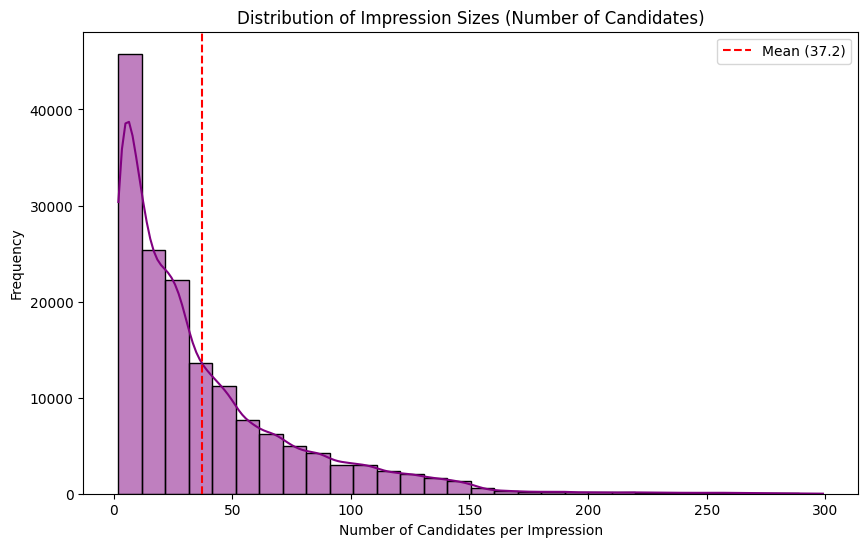

In [45]:
# 5. Histogram of Impression Sizes
plt.figure(figsize=(10, 6))
sns.histplot(behaviors_df['imp_size'], bins=30, color='purple', kde=True)
plt.title('Distribution of Impression Sizes (Number of Candidates)')
plt.xlabel('Number of Candidates per Impression')
plt.ylabel('Frequency')
plt.axvline(avg_candidates, color='red', linestyle='--', label=f'Mean ({avg_candidates:.1f})')
plt.legend()
plt.savefig('results/impression_size_dist.png')
plt.show()

## Interpretation — Impression Size Analysis
The distribution of impression sizes shows that most impressions contain a small number of candidate items, with frequency starting very high at low candidate counts and decreasing sharply as impression size increases. Although the mean impression size is 37.2, the rapid downward slope indicates a right-skewed distribution where large impressions are relatively rare compared to smaller ones. A potential data quality issue is imbalance in impression sizes, which may affect model evaluation since users exposed to larger candidate sets can influence click probability and ranking performance differently.

### Temporal Patterns

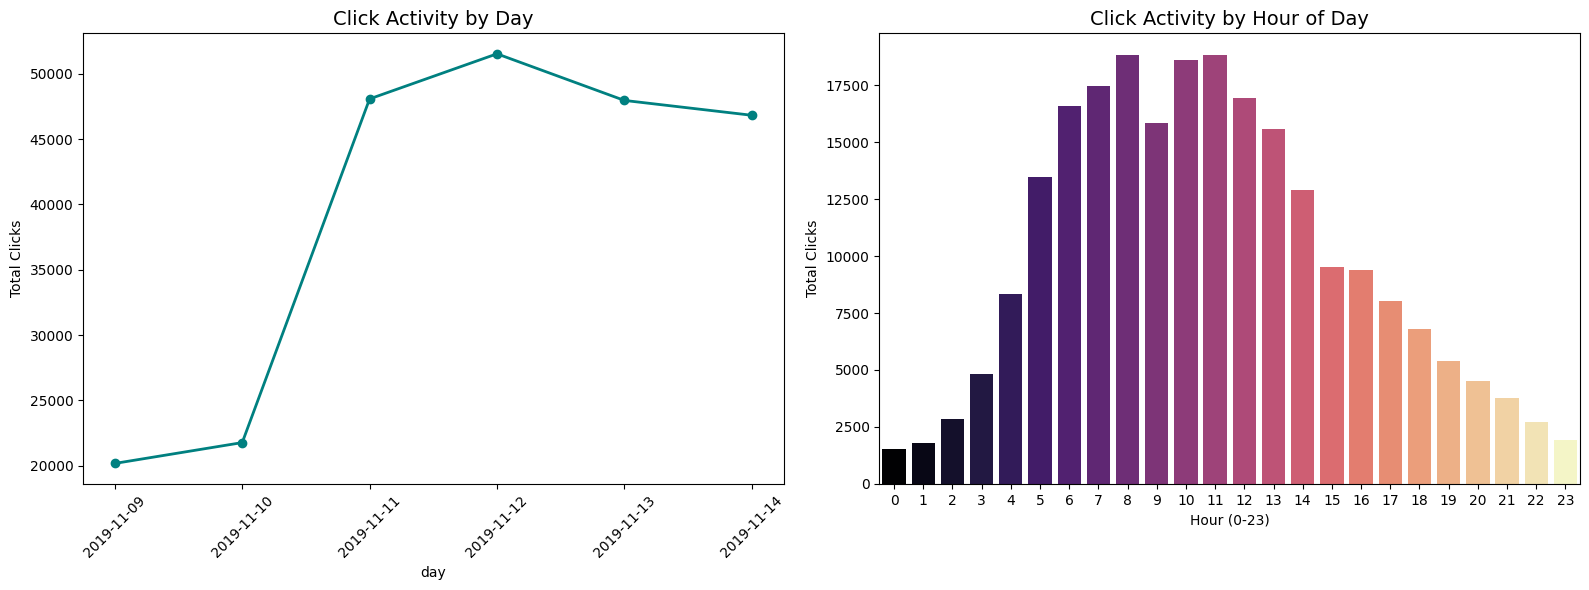

Peak news consumption hour: 8:00


In [48]:
# 1. Convert 'time' to datetime and extract temporal features
behaviors_df['time'] = pd.to_datetime(behaviors_df['time'])
behaviors_df['day'] = behaviors_df['time'].dt.date
behaviors_df['hour'] = behaviors_df['time'].dt.hour

# 2. Count clicks (occurrences of '-1')
behaviors_df['click_count'] = behaviors_df['impressions'].str.count('-1')

# 3. Aggregate activity
daily_activity = behaviors_df.groupby('day')['click_count'].sum()
hourly_activity = behaviors_df.groupby('hour')['click_count'].sum()

# 4. Visualization
plt.figure(figsize=(16, 6))

# Subplot 1: Daily Trends
plt.subplot(1, 2, 1)
daily_activity.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title('Click Activity by Day', fontsize=14)
plt.ylabel('Total Clicks')
plt.xticks(rotation=45)

# Subplot 2: Hourly Distribution
plt.subplot(1, 2, 2)
sns.barplot(x=hourly_activity.index, y=hourly_activity.values, hue=hourly_activity.index, palette='magma', legend=False)
plt.title('Click Activity by Hour of Day', fontsize=14)
plt.xlabel('Hour (0-23)')
plt.ylabel('Total Clicks')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/temporal_patterns.png')
plt.show()

# Print summary findings
print(f"Peak news consumption hour: {hourly_activity.idxmax()}:00")

## Interpretation - Temporal patterms
News consumption peaks sharply at 8:00 AM, remains elevated until around 11:00, and then gradually declines for the rest of the day, suggesting strong morning-driven engagement. Across the Nov 9–14 window, total clicks rise to a clear peak on Nov 12 before tapering off, indicating a short-lived spike in interest or event-driven traffic.
A potential data quality concern is the apparent single-day sharp peak on Nov 12, which could reflect either a real external event or an anomaly such as duplicated clicks, tracking inconsistency, or uneven data collection across days. Additionally, if timestamps are aggregated without timezone normalization, the strong 8:00 AM peak could be partially distorted by shifted logging times.

### Text Statistics

In [51]:
from wordcloud import WordCloud

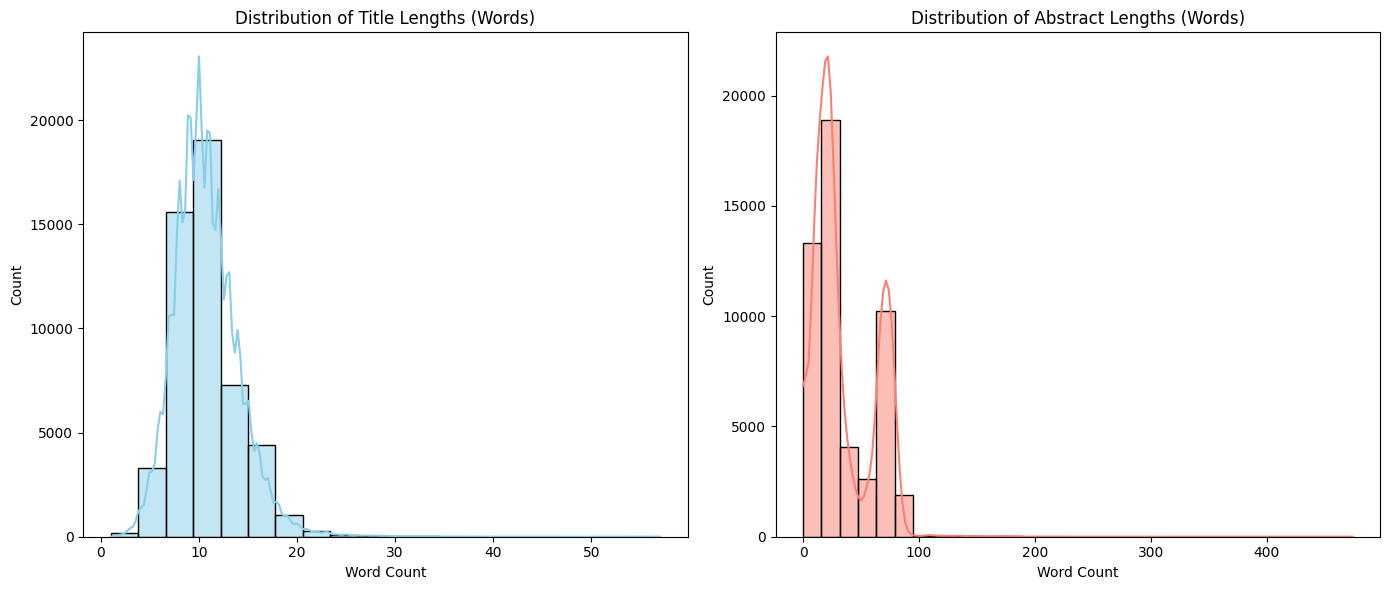

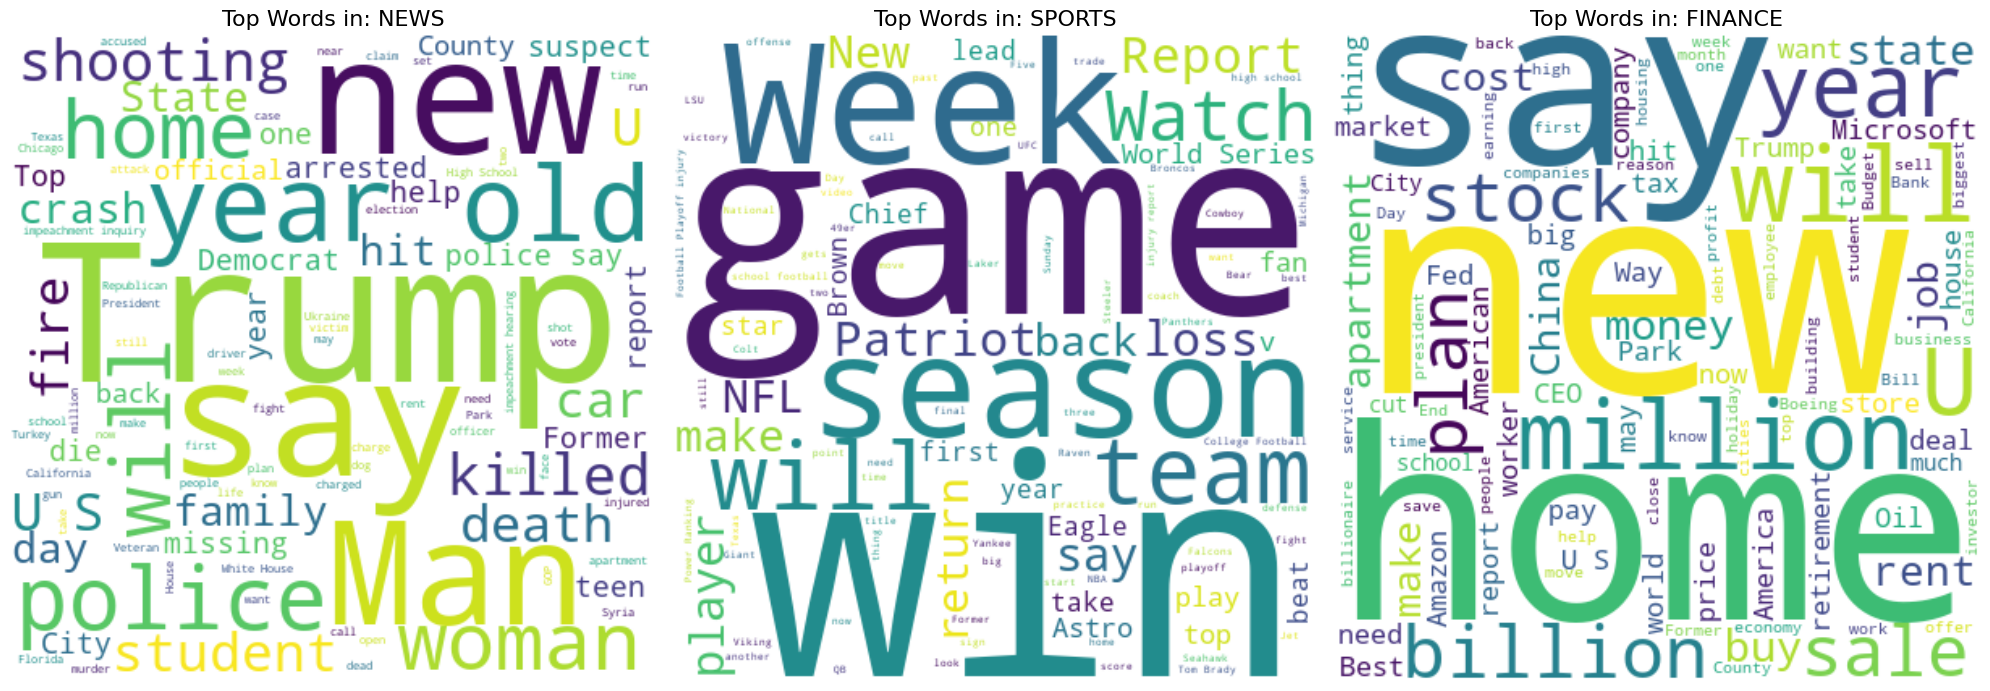

Average Title Length: 10.75 words
Average Abstract Length: 34.29 words


In [52]:
# 1. Calculate word counts (handling NaNs in abstracts)
news_df['title_word_count'] = news_df['title'].str.split().str.len()
news_df['abs_word_count'] = news_df['abstract'].fillna('').str.split().str.len()

# 2. Plot Distributions
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(news_df['title_word_count'], bins=20, color='skyblue', kde=True)
plt.title('Distribution of Title Lengths (Words)')
plt.xlabel('Word Count')

plt.subplot(1, 2, 2)
sns.histplot(news_df['abs_word_count'], bins=30, color='salmon', kde=True)
plt.title('Distribution of Abstract Lengths (Words)')
plt.xlabel('Word Count')

plt.tight_layout()
plt.savefig('results/text_length_distribution.png')
plt.show()

# 3. Generate Word Clouds for Top 3 Categories
top_categories = news_df['category'].value_counts().nlargest(3).index
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

for i, cat in enumerate(top_categories):
    # Combine all titles for the specific category
    text = " ".join(title for title in news_df[news_df['category'] == cat]['title'].astype(str))
    
    wordcloud = WordCloud(width=400, height=400, background_color='white', 
                          colormap='viridis', max_words=100).generate(text)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'Top Words in: {cat.upper()}', fontsize=16)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('results/category_wordclouds.png')
plt.show()

# Print averages
print(f"Average Title Length: {news_df['title_word_count'].mean():.2f} words")
print(f"Average Abstract Length: {news_df['abs_word_count'].mean():.2f} words")

## Interpretation - Text statistics (Title length distribution)
The dataset shows relatively concise content, with headlines averaging 10.75 words and abstracts averaging 34.29 words, suggesting a format optimized for quick consumption while still providing brief context. This balance is typical of news-style data where titles are designed for scanning and abstracts for short summaries.
A potential data quality issue is the lack of variability information (e.g., distribution, min/max, or outliers), which makes it difficult to assess whether a few unusually long or short entries are skewing the averages. It’s also worth verifying consistent tokenization (e.g., how punctuation, hyphenated words, or encoding artifacts were handled), as these can slightly distort word counts.

Be;pw those charts I have displayed Top Words in News, Sportsm and Finance. Larger font words equate to more frequency in their respective category.